# 2 - Deep convolutional GAN


> Part of **[Compressed Sensing using Generative Models](../README.md)**.
> Run `pip install -e .` from the repository root first; every notebook imports
> the `csgm` package rather than redefining the model and recovery code inline.


A GAN reaches the same goal as the VAE - a differentiable map
$G : \mathbb{R}^k \to \mathbb{R}^n$ whose range is the data manifold - by a very
different route. Instead of maximising a likelihood bound, a discriminator $D$
is trained to tell real digits from generated ones while $G$ is trained to fool
it:

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))].$$

There is no encoder, so there is no cheap way to ask "which $z$ produced this
image?" - which is precisely the question compressed sensing recovery answers by
optimisation.

In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np

from csgm.config import DEFAULT_SEED, MODELS_DIR
from csgm.data import load_mnist
from csgm.models import DCGAN, GANMonitor, build_discriminator, build_generator
from csgm.viz import show_images

keras.utils.set_random_seed(DEFAULT_SEED)

## 2.1 Data

Train and test splits are concatenated. A GAN is a density model that is never
evaluated against labels, so holding 10k digits back would only waste signal.

In [2]:
(x_train, _), (x_test, _) = load_mnist()
dataset = np.concatenate([x_train, x_test])
print("training on", dataset.shape)

training on (70000, 28, 28, 1)


## 2.2 Architecture

Both networks follow the DCGAN recipe (Radford et al., 2015): strided
convolutions instead of pooling, LeakyReLU activations, no fully connected
hidden layers beyond the projection of $z$.

| | generator | discriminator |
|---|---|---|
| input | $z \in \mathbb{R}^k$ | $28 \times 28 \times 1$ image |
| body | dense $\to 3{\times}3{\times}128$, then 3 transposed convolutions (128, 256, 512) | 3 strided convolutions (64, 128, 128) |
| output | $28 \times 28 \times 1$, sigmoid | scalar, sigmoid |

| | generator, $k=20$ | discriminator |
|---|---|---|
| parameters | 2,921,473 | 396,609 |
| spatial cascade | $3^2 \to 6^2 \to 14^2 \to 28^2$ | $28^2 \to 14^2 \to 7^2 \to 4^2$ |

The generator is about seven times the size of the discriminator, which is the
usual arrangement: it has the harder job.

In [3]:
latent_dim = 20

generator = build_generator(latent_dim)
discriminator = build_discriminator()
generator.summary()
discriminator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1152)           │        24,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 6, 6, 128)      │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,921,473 (11.14 MB)

 Trainable params: 2,921,473 (11.14 MB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,609 (1.51 MB)

 Trainable params: 396,609 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

## 2.3 Training

Each step updates $D$ on a half-real / half-fake batch, then updates $G$ against
the refreshed $D$. Two details keep the game stable:

- **label smoothing by noise** - discriminator targets are perturbed by
  $\mathcal{U}(0, 0.05)$, which stops $D$ from saturating and starving $G$ of
  gradient;
- **equal learning rates** ($10^{-4}$ for both) - a discriminator that learns
  faster than the generator wins outright and training stalls.

The shipped checkpoints were trained for 50 epochs at batch size 32.
Adversarial training has no convergence criterion to monitor, so `GANMonitor`
writes a fixed grid of samples every epoch and the sheets are inspected by eye.
The cell below runs two epochs, just enough to see the loop working.

```bash
python scripts/train_dcgan.py --latent-dim 20 --epochs 50
```

In [4]:
EPOCHS = 2  # -> 50 to reproduce the checkpoints

gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    g_optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss_fn=keras.losses.BinaryCrossentropy(),
)
history = gan.fit(
    dataset,
    epochs=EPOCHS,
    batch_size=32,
    callbacks=[GANMonitor("../results/samples/notebook_demo", num_images=10)],
    verbose=2,  # one line per epoch, instead of a progress bar redrawn per batch
)

Epoch 1/2


2188/2188 - 1963s - 897ms/step - d_loss: 0.3742 - g_loss: 7.4586


Epoch 2/2


2188/2188 - 2072s - 947ms/step - d_loss: 0.5347 - g_loss: 1.3236


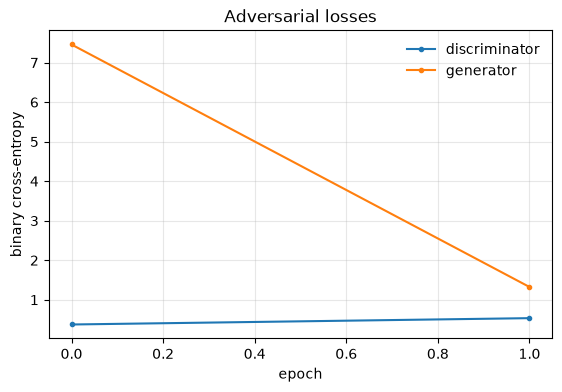

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(history.history["d_loss"], marker="o", ms=3, label="discriminator")
ax.plot(history.history["g_loss"], marker="o", ms=3, label="generator")
ax.set_xlabel("epoch")
ax.set_ylabel("binary cross-entropy")
ax.set_title("Adversarial losses")
ax.grid(alpha=0.3)
ax.legend(frameon=False);

Unlike the VAE curves, these losses are **not** a quality signal: they measure
who is currently winning, not how good the samples are. A generator loss that
falls to zero usually means the discriminator has collapsed, not that the digits
look good. Sample sheets are the real diagnostic.

## 2.4 Samples

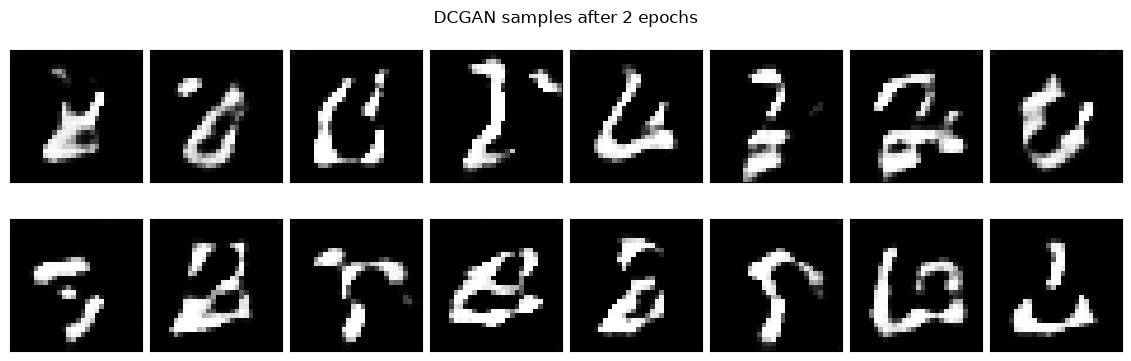

In [6]:
z = np.random.default_rng(0).standard_normal((16, latent_dim)).astype("float32")
show_images(generator(z, training=False), suptitle=f"DCGAN samples after {EPOCHS} epochs");

Two epochs are nowhere near enough for clean digits, which is an honest picture
of how slowly adversarial training converges. The shipped checkpoint was trained
for 50 epochs; loading it shows what the recovery experiments actually work with.

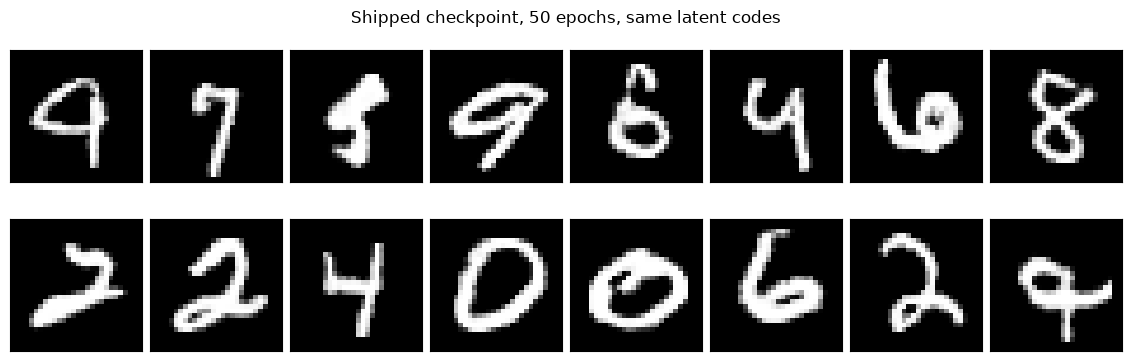

In [7]:
from csgm.models import load_generator

trained = load_generator("dcgan", latent_dim)
show_images(trained(z, training=False), suptitle="Shipped checkpoint, 50 epochs, same latent codes");

## 2.5 Why two latent dimensions were trained

$k$ trades expressiveness against searchability. A larger latent space can
represent more digits faithfully, but recovery has to optimise over more
variables from the same number of measurements - and the sample-complexity bound
of Bora et al. grows as $O(k \log L)$. Both $k = 20$ and $k = 30$ were trained so
that trade-off can be measured rather than guessed; see
[notebook 4](04_compressed_sensing_recovery.ipynb).

In [8]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
# generator.save(MODELS_DIR / f"gan_gen_dim{latent_dim}.keras")       # uncomment to overwrite
# discriminator.save(MODELS_DIR / f"gan_disc_dim{latent_dim}.keras")
print("checkpoints stay untouched")

checkpoints stay untouched


---
Next: [3 - Lasso baseline](03_lasso_baseline.ipynb), the sparsity prior the
learned priors are compared against.